# Dashboard do Corpus STIL 2023

Este notebook para Google Colab importa o JSON dos artigos, agrega o corpus, calcula estatísticas textuais e exibe um dashboard com tabelas, gráficos e nuvem de palavras.

Requisitos atendidos:
- importar o corpus dos artigos
- tokenizar e quantificar
- não retirar stopwords
- quantidade de tokens e types
- quantidade de sentenças
- quantidade por classe gramatical
- quantidade de lemas
- top 10 palavras do corpus
- nuvem de palavras

In [1]:
# Dependências instaladas no ambiente local.

## Etapa 1: carregar o arquivo JSON

Você pode subir o arquivo `stil2023_articles.json` gerado pelo scraper. Se preferir, também pode montar o Google Drive e apontar para o caminho do arquivo.

In [2]:
from pathlib import Path
json_path = Path(r'D:\scrapy_article\artigo_sbc\stil2023_articles.json')
print(f'Arquivo carregado: {json_path}')


Arquivo carregado: D:\scrapy_article\artigo_sbc\stil2023_articles.json


## Etapa 2: importar bibliotecas e definir funções auxiliares

As funções abaixo fazem a leitura do corpus, a agregação dos campos e o cálculo das estatísticas.

In [3]:
import json
import math
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, display
from wordcloud import WordCloud


WORD_RE = re.compile(r"\w", re.UNICODE)
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def load_articles(path: str):
    """Carrega o JSON de artigos produzido pelo scraper."""
    # Abre o arquivo no formato UTF-8 para preservar acentos do portugu?s.
    with open(path, encoding="utf-8") as f:
        # Converte o JSON em uma lista de dicion?rios Python.
        return json.load(f)


def sentence_count(text: str) -> int:
    """Conta senten?as de forma simples usando pontua??o final."""
    # Garante que texto vazio ou None n?o quebre a fun??o.
    text = (text or "").strip()
    if not text:
        return 0

    # Divide o texto sempre que encontrar espa?o depois de ponto, exclama??o ou interroga??o.
    parts = [p.strip() for p in SENTENCE_SPLIT_RE.split(text) if p.strip()]
    return len(parts) if parts else 1


def is_word_token(token: str) -> bool:
    """Considera como palavra qualquer token com pelo menos um caractere alfanum?rico."""
    # Filtra pontua??es isoladas, espa?os e valores vazios.
    return bool(WORD_RE.search(token or ""))


def build_corpus_stats(articles):
    """Agrega tokens, lemas, POS e senten?as do corpus inteiro."""
    # Estas listas juntam as informa??es de todos os artigos em um corpus ?nico.
    all_tokens = []
    all_word_tokens = []
    all_pos = []
    all_lemmas = []
    sentence_total = 0
    full_texts = []

    # Cada artigo do JSON contribui com texto, tokens, classes gramaticais e lemas.
    for article in articles:
        text = article.get("artigo_completo", "") or ""
        tokens = article.get("artigo_tokenizado", []) or []
        pos_tags = article.get("pos_tagger", []) or []
        lemmas = article.get("lema", []) or []

        # Soma estat?sticas do artigo atual ao acumulado geral.
        sentence_total += sentence_count(text)
        full_texts.append(text)
        all_tokens.extend(tokens)
        all_word_tokens.extend([token for token in tokens if is_word_token(token)])
        all_pos.extend(pos_tags)
        all_lemmas.extend([lemma for lemma in lemmas if is_word_token(lemma)])

    # Counter calcula a frequ?ncia de cada palavra, classe gramatical e lema.
    token_counter = Counter(all_word_tokens)
    pos_counter = Counter(all_pos)
    lemma_counter = Counter(all_lemmas)

    # O dicion?rio retornado centraliza tudo que ser? usado nos gr?ficos e tabelas.
    return {
        "articles": articles,
        "texts": full_texts,
        "all_tokens": all_tokens,
        "all_word_tokens": all_word_tokens,
        "all_pos": all_pos,
        "all_lemmas": all_lemmas,
        "sentence_total": sentence_total,
        "token_counter": token_counter,
        "pos_counter": pos_counter,
        "lemma_counter": lemma_counter,
        "token_total": len(all_word_tokens),
        "type_total": len(set(token.casefold() for token in all_word_tokens)),
        "lemma_total": len(set(lemma.casefold() for lemma in all_lemmas)),
    }


def top_words_df(stats, n=10):
    """Retorna o top N de palavras do corpus sem remover stopwords."""
    # Monta linhas no formato adequado para exibir como tabela pandas.
    rows = []
    for token, freq in stats["token_counter"].most_common(n):
        rows.append({"palavra": token, "frequencia": freq})
    return pd.DataFrame(rows)


def pos_df(stats):
    """Retorna a distribui??o de classes gramaticais."""
    # Transforma o contador de POS em tabela ordenada por frequ?ncia.
    rows = [{"classe_gramatical": tag, "frequencia": freq} for tag, freq in stats["pos_counter"].most_common()]
    return pd.DataFrame(rows)


def article_df(articles):
    """Cria uma tabela resumida por artigo."""
    rows = []
    for article in articles:
        # Calcula m?tricas individuais para comparar os artigos entre si.
        rows.append({
            "titulo": article.get("titulo", ""),
            "idioma": article.get("idioma", ""),
            "tokens": len([t for t in article.get("artigo_tokenizado", []) if is_word_token(t)]),
            "types": len(set((t.casefold() for t in article.get("artigo_tokenizado", []) if is_word_token(t)))),
            "sentencas": sentence_count(article.get("artigo_completo", "") or ""),
            "lemmas": len(set((l.casefold() for l in article.get("lema", []) if is_word_token(l)))),
        })
    return pd.DataFrame(rows)


def make_summary_cards(stats, articles):
    """Exibe cart?es HTML com os indicadores principais do corpus."""
    # Define os indicadores que aparecem no topo do dashboard.
    cards = [
        ("Artigos", len(articles)),
        ("Tokens", f"{stats['token_total']:,}"),
        ("Types", f"{stats['type_total']:,}"),
        ("Senten?as", f"{stats['sentence_total']:,}"),
        ("Lemmas", f"{stats['lemma_total']:,}"),
    ]

    # O HTML abaixo cria cart?es simples para melhorar a leitura no Colab.
    html = """
    <div style='display:flex; gap:16px; flex-wrap:wrap; margin:16px 0;'>
    """
    for label, value in cards:
        html += f"""
        <div style='min-width:170px; padding:18px; border-radius:14px; background:#f4f7fb; border:1px solid #dbe4f0;'>
          <div style='font-size:14px; color:#4c5a67; margin-bottom:6px;'>{label}</div>
          <div style='font-size:28px; font-weight:700; color:#17324d;'>{value}</div>
        </div>
        """
    html += "</div>"
    display(HTML(html))


def plot_top_words(stats, n=10):
    """Plota o top N de palavras do corpus."""
    # Usa a tabela de frequ?ncias para desenhar um gr?fico de barras.
    df = top_words_df(stats, n=n)
    fig = px.bar(df, x="palavra", y="frequencia", title=f"Top {n} palavras do corpus", text_auto=True)
    fig.update_layout(xaxis_title="Palavra", yaxis_title="Frequ?ncia")
    fig.show()


def plot_pos_distribution(stats):
    """Plota a distribui??o das classes gramaticais."""
    # Mostra quais classes gramaticais aparecem mais no corpus.
    df = pos_df(stats)
    fig = px.bar(df, x="classe_gramatical", y="frequencia", title="Quantidade por classe gramatical", text_auto=True)
    fig.update_layout(xaxis_title="Classe gramatical", yaxis_title="Frequ?ncia")
    fig.show()


def plot_article_tokens(articles):
    """Plota a quantidade de tokens por artigo."""
    # Ordena os artigos do maior para o menor para facilitar a compara??o.
    df = article_df(articles).sort_values("tokens", ascending=False)
    fig = px.bar(df, x="titulo", y="tokens", title="Quantidade de tokens por artigo")
    fig.update_layout(xaxis_title="Artigo", yaxis_title="Tokens")
    fig.show()


def plot_wordcloud(stats):
    """Gera a nuvem de palavras a partir das frequ?ncias do corpus sem remover stopwords."""
    # A nuvem usa as frequ?ncias: palavras mais comuns aparecem maiores.
    wc = WordCloud(width=1600, height=800, background_color="white", colormap="viridis")
    wc.generate_from_frequencies(stats["token_counter"])
    plt.figure(figsize=(18, 9))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nuvem de palavras do corpus STIL 2023", fontsize=18)
    plt.show()


def render_dashboard(stats):
    """Renderiza o dashboard completo com indicadores, tabelas, gr?ficos e wordcloud."""
    # Esta fun??o organiza a ordem em que os resultados aparecem no notebook.
    articles = stats["articles"]
    make_summary_cards(stats, articles)
    display(top_words_df(stats, n=10))
    display(pos_df(stats))
    display(article_df(articles))
    plot_top_words(stats, n=10)
    plot_pos_distribution(stats)
    plot_article_tokens(articles)
    plot_wordcloud(stats)


## O que cada função faz

- `load_articles(path)`: lê o arquivo JSON e retorna a lista de artigos.
- `sentence_count(text)`: estima a quantidade de sentenças do texto.
- `is_word_token(token)`: filtra tokens para considerar apenas palavras, removendo pontuação isolada.
- `build_corpus_stats(articles)`: agrega o corpus inteiro e calcula os contadores principais.
- `top_words_df(stats, n)`: monta a tabela do top N palavras do corpus, sem retirar stopwords.
- `pos_df(stats)`: monta a tabela de frequência por classe gramatical.
- `article_df(articles)`: gera uma tabela resumida por artigo.
- `make_summary_cards(stats, articles)`: cria cartões com os indicadores centrais do corpus.
- `plot_top_words(stats, n)`: desenha o gráfico do top N palavras.
- `plot_pos_distribution(stats)`: desenha o gráfico das classes gramaticais.
- `plot_article_tokens(articles)`: mostra a distribuição de tokens por artigo.
- `plot_wordcloud(stats)`: gera a nuvem de palavras do corpus.
- `render_dashboard(stats)`: junta tudo e renderiza o dashboard completo.

## Etapa 3: construir o corpus agregado

In [4]:
articles = load_articles(json_path)
stats = build_corpus_stats(articles)

print(f"Artigos carregados: {len(articles)}")
print(f"Tokens: {stats['token_total']}")
print(f"Types: {stats['type_total']}")
print(f"Sentenças: {stats['sentence_total']}")
print(f"Lemmas: {stats['lemma_total']}")

Artigos carregados: 30
Tokens: 104575
Types: 14475
Sentenças: 6402
Lemmas: 14383


## Etapa 4: renderizar o dashboard

,palavra,frequencia
0,de,3689
1,a,2249
2,ao,2013
3,e,1935
4,the,1236
5,o,1212
6,of,1054
7,que,1045
8,em,1020
9,and,926


,classe_gramatical,frequencia
0,NOUN,50975
1,PUNCT,39535
2,PROPN,18318
3,ADP,10183
4,NUM,7068
5,DET,6734
6,VERB,3387
7,CCONJ,2437
8,ADJ,2267
9,SCONJ,1027


,titulo,idioma,tokens,types,sentencas,lemmas
0,A call for a research agenda on fair NLP for P...,Português,2536,908,222,907
1,A dependency-based study of medicine package i...,Português,2313,1062,166,1062
2,A funcionalidade dos adjetivos em dois gêneros...,Português,4393,1320,283,1313
3,Abordagens Baseadas em Léxicos para a Classifi...,Português,2785,896,186,896
4,Annotation of fixed Multiword Expressions (MWE...,Português,4321,1209,189,1209
5,Anotação do Dataset Multimodal da ReINVenTA,Português,841,597,61,593
6,Aposições anafóricas e catafóricas no portuguê...,Português,3989,1265,297,1258
7,Aryon: um aplicativo Shiny para documentação e...,Português,1633,615,84,615
8,Avaliação do senso comum em modelos de linguag...,Português,2388,978,162,973
9,Características gerais das leis federais brasi...,Português,4129,1386,269,1374


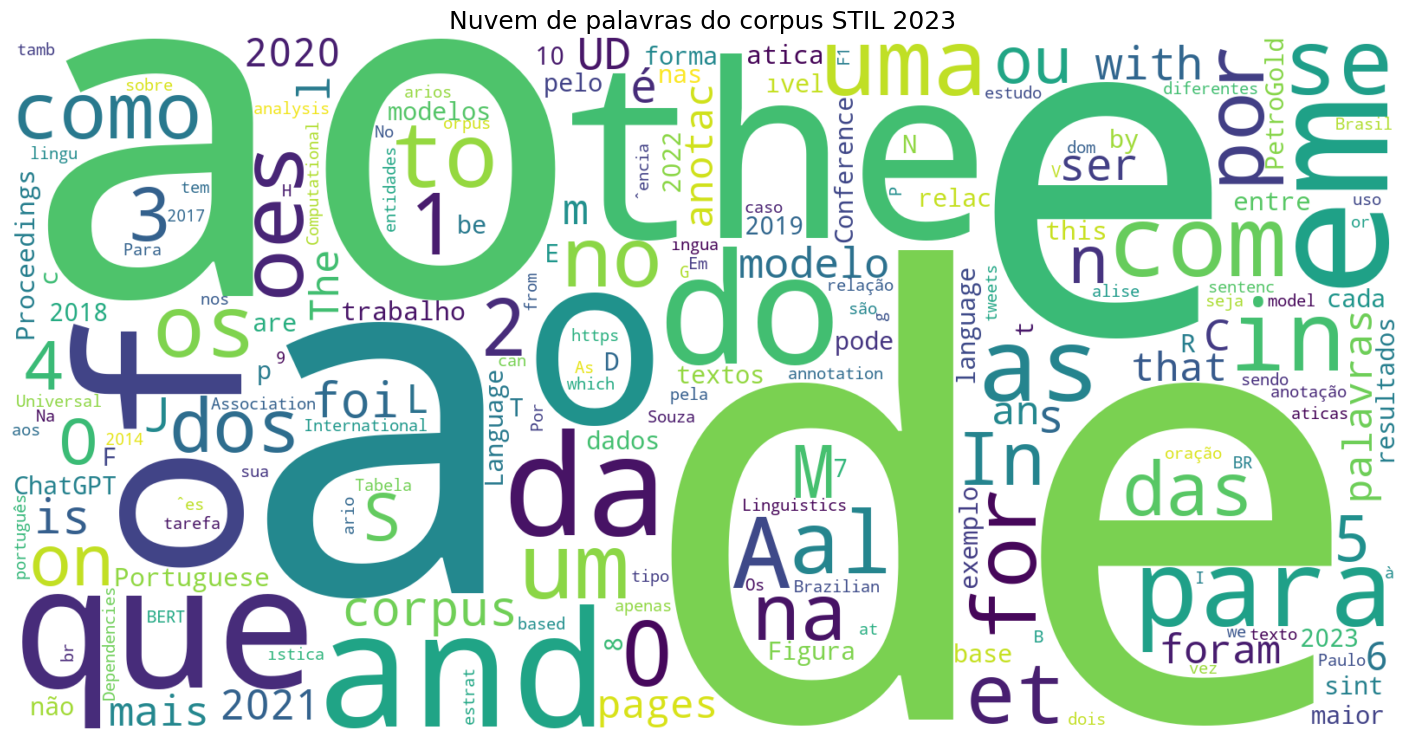

In [5]:
render_dashboard(stats)

## Etapa 5: exportar as tabelas, se quiser

Estas células salvam as estatísticas em CSV para download posterior.

In [6]:
top_words_df(stats, n=10).to_csv("top10_palavras.csv", index=False, encoding="utf-8")
pos_df(stats).to_csv("classes_gramaticais.csv", index=False, encoding="utf-8")
article_df(articles).to_csv("estatisticas_por_artigo.csv", index=False, encoding="utf-8")

print("Arquivos CSV gerados com sucesso.")

Arquivos CSV gerados com sucesso.


## Etapa 6: matriz termo x termo, probabilidades e frequencias de n-gramas

Esta etapa usa NLTK para criar frequencias de unigramas, bigramas e trigramas. A matriz de bigramas representa `termo_atual x proximo_termo`. A matriz de trigramas representa `termo_1 termo_2 x proximo_termo`. Alem das frequencias, tambem sao calculadas matrizes de probabilidade condicional, isto e, a probabilidade de um termo aparecer dado o contexto anterior.

In [7]:
import math
import random
from nltk import ngrams, FreqDist
from langdetect import DetectorFactory, LangDetectException, detect

DetectorFactory.seed = 0


def repair_encoding(value):
    """Corrige casos comuns de mojibake antes de montar n-gramas."""
    # Se o texto n?o tiver sinais de encoding quebrado, n?o tenta corrigir.
    if not value or not any(marker in value for marker in ("?", "?", "?")):
        return value
    try:
        # Alguns textos foram lidos como latin1 quando eram UTF-8; esta linha tenta desfazer isso.
        repaired = value.encode("latin1").decode("utf-8")
        return repaired if repaired.count("?") < value.count("?") else value
    except Exception:
        return value


def article_text_for_language_model(article):
    """Usa a vers?o em portugu?s do artigo quando ela est? dispon?vel."""
    # Prioriza os campos traduzidos para portugu?s, para evitar treinar o modelo em ingl?s.
    portuguese_text = article.get("artigo_completo_pt") or article.get("resumo_pt") or ""
    original_text = article.get("artigo_completo") or article.get("resumo") or ""
    return repair_encoding(portuguese_text or original_text)


URL_OR_REFERENCE_RE = re.compile(r"(https?://|www\.|\bdoi\b|@|\barxiv\b)", re.IGNORECASE)


def sentence_looks_portuguese(sentence):
    """Usa langdetect para manter apenas senten?as classificadas como portugu?s."""
    sentence = repair_encoding(sentence)
    words = re.findall(r"[A-Za-z?-?]+", sentence, flags=re.UNICODE)
    if len(words) < 4:
        return False

    # Remove trechos t?picos de refer?ncia, URL, DOI e e-mail antes da detec??o de idioma.
    if URL_OR_REFERENCE_RE.search(sentence):
        return False

    try:
        return detect(sentence) == "pt"
    except LangDetectException:
        return False


def portuguese_sentences_for_language_model(article):
    """Divide o artigo e preserva apenas senten?as detectadas como portugu?s."""
    text = article_text_for_language_model(article)
    sentences = [sentence.strip() for sentence in SENTENCE_SPLIT_RE.split(text) if sentence.strip()]
    return [sentence for sentence in sentences if sentence_looks_portuguese(sentence)]


def text_word_tokens(text, lowercase=True):
    """Tokeniza texto corrido em palavras para treinar o modelo em portugu?s."""
    # Extrai apenas palavras com letras, preservando caracteres acentuados.
    words = re.findall(r"[A-Za-z?-?]+", repair_encoding(text), flags=re.UNICODE)
    return [word.casefold() if lowercase else word for word in words if is_word_token(word)]


def corpus_word_tokens(articles, lowercase=True):
    """Retorna tokens-palavra usando apenas senten?as que parecem portugu?s."""
    tokens = []
    for article in articles:
        # Junta apenas senten?as em portugu?s para reduzir Abstracts, refer?ncias e URLs em ingl?s.
        for sentence in portuguese_sentences_for_language_model(article):
            tokens.extend(text_word_tokens(sentence, lowercase=lowercase))
    return tokens


def ngram_counter(tokens, n):
    """Conta n-gramas de tamanho n usando NLTK."""
    # n=1 gera unigramas; n=2 gera bigramas; n=3 gera trigramas.
    return FreqDist(ngrams(tokens, n))


def ngram_frequency_df(counter, n, top=None):
    """Converte um contador de n-gramas em DataFrame ordenado por frequencia."""
    rows = []
    total = sum(counter.values()) or 1
    for gram, freq in counter.most_common(top):
        # A probabilidade aqui ? a frequ?ncia do n-grama dividida pelo total de n-gramas.
        rows.append({
            "ngrama": " ".join(gram),
            "frequencia": freq,
            "probabilidade": freq / total,
            **{f"termo_{i + 1}": term for i, term in enumerate(gram)},
        })
    return pd.DataFrame(rows)


def bigram_matrix(tokens, min_frequency=2, max_terms=60):
    """Cria matriz termo x termo com frequencias de co-ocorrencia adjacente."""
    bigrams = ngram_counter(tokens, 2)
    # Limita a matriz aos termos mais frequentes para ela ficar leg?vel no Colab.
    frequent_terms = [term for term, _ in Counter(tokens).most_common(max_terms)]
    matrix = pd.DataFrame(0, index=frequent_terms, columns=frequent_terms)
    for (left, right), freq in bigrams.items():
        # Linha = termo atual; coluna = pr?ximo termo; valor = frequ?ncia do bigrama.
        if freq >= min_frequency and left in matrix.index and right in matrix.columns:
            matrix.loc[left, right] = freq
    return matrix


def trigram_context_matrix(tokens, min_frequency=2, max_contexts=60, max_next_terms=60):
    """Cria matriz contexto bigrama x proximo termo com frequencias de trigramas."""
    trigrams = ngram_counter(tokens, 3)
    # No trigrama, as duas primeiras palavras formam o contexto da linha.
    context_counter = Counter((a, b) for (a, b, _), freq in trigrams.items() for _ in range(freq))
    next_counter = Counter(c for (_, _, c), freq in trigrams.items() for _ in range(freq))
    contexts = [" ".join(context) for context, _ in context_counter.most_common(max_contexts)]
    next_terms = [term for term, _ in next_counter.most_common(max_next_terms)]
    matrix = pd.DataFrame(0, index=contexts, columns=next_terms)
    for (a, b, c), freq in trigrams.items():
        # Linha = duas palavras anteriores; coluna = pr?xima palavra; valor = frequ?ncia do trigrama.
        context = f"{a} {b}"
        if freq >= min_frequency and context in matrix.index and c in matrix.columns:
            matrix.loc[context, c] = freq
    return matrix


def conditional_probability_matrix(frequency_matrix):
    """Normaliza cada linha da matriz para obter P(proximo termo | contexto)."""
    # A soma da linha ? o total de vezes que aquele contexto apareceu.
    row_totals = frequency_matrix.sum(axis=1).replace(0, pd.NA)
    # Dividir cada c?lula pelo total da linha transforma frequ?ncia em probabilidade condicional.
    return frequency_matrix.div(row_totals, axis=0).fillna(0)


# tokens_lm ? a base usada para n-gramas, matrizes, perplexidade e gera??o de texto.
tokens_lm = corpus_word_tokens(articles)
unigram_counts = ngram_counter(tokens_lm, 1)
unigram_token_counts = FreqDist(tokens_lm)
bigram_counts = ngram_counter(tokens_lm, 2)
trigram_counts = ngram_counter(tokens_lm, 3)

# Tabelas resumidas dos n-gramas mais frequentes.
unigram_df = ngram_frequency_df(unigram_counts, 1, top=30)
bigram_df = ngram_frequency_df(bigram_counts, 2, top=30)
trigram_df = ngram_frequency_df(trigram_counts, 3, top=30)

# Matrizes de frequ?ncia e probabilidade usadas na an?lise termo-termo.
bigram_cooccurrence_matrix = bigram_matrix(tokens_lm, min_frequency=2, max_terms=60)
trigram_cooccurrence_matrix = trigram_context_matrix(tokens_lm, min_frequency=2, max_contexts=60, max_next_terms=60)
bigram_probability_matrix = conditional_probability_matrix(bigram_cooccurrence_matrix)
trigram_probability_matrix = conditional_probability_matrix(trigram_cooccurrence_matrix)

print(f"Tokens usados no modelo: {len(tokens_lm)}")
print(f"Unigramas distintos: {len(unigram_counts)}")
print(f"Bigramas distintos: {len(bigram_counts)}")
print(f"Trigramas distintos: {len(trigram_counts)}")


Tokens usados no modelo: 64806
Unigramas distintos: 7936
Bigramas distintos: 32907
Trigramas distintos: 51121


C:\Users\murilo.lima\AppData\Local\Temp\ipykernel_17068\388142158.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frequency_matrix.div(row_totals, axis=0).fillna(0)
C:\Users\murilo.lima\AppData\Local\Temp\ipykernel_17068\388142158.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frequency_matrix.div(row_totals, axis=0).fillna(0)


In [8]:
display(unigram_df)
display(bigram_df)
display(trigram_df)

print("Matriz de frequencia - bigramas")
display(bigram_cooccurrence_matrix)
print("Matriz de probabilidade - bigramas")
display(bigram_probability_matrix)

print("Matriz de frequencia - trigramas")
display(trigram_cooccurrence_matrix)
print("Matriz de probabilidade - trigramas")
display(trigram_probability_matrix)


,ngrama,frequencia,probabilidade,termo_1
0,de,3399,0.052449,de
1,o,2419,0.037327,o
2,a,2089,0.032235,a
3,ao,1913,0.029519,ao
4,e,1780,0.027467,e
5,em,1044,0.016110,em
6,que,1004,0.015492,que
7,do,804,0.012406,do
8,para,739,0.011403,para
9,da,655,0.010107,da


,ngrama,frequencia,probabilidade,termo_1,termo_2
0,ao de,284,0.004382,ao,de
1,et al,211,0.003256,et,al
2,o de,165,0.002546,o,de
3,n ao,149,0.002299,n,ao
4,para o,129,0.001991,para,o
5,para a,129,0.001991,para,a
6,anotac ao,129,0.001991,anotac,ao
7,s ao,126,0.001944,s,ao
8,l ngua,120,0.001852,l,ngua
9,s o,113,0.001744,s,o


,ngrama,frequencia,probabilidade,termo_1,termo_2,termo_3
0,de anotac ao,48,0.000741,de,anotac,ao
1,l ngua portuguesa,47,0.000725,l,ngua,portuguesa
2,de anota o,45,0.000694,de,anota,o
3,anota o de,39,0.000602,anota,o,de
4,de opini ao,39,0.000602,de,opini,ao
5,em portugu es,37,0.000571,em,portugu,es
6,classificac ao de,36,0.000556,classificac,ao,de
7,o portugu es,35,0.000540,o,portugu,es
8,ao sint atica,34,0.000525,ao,sint,atica
9,de depend ncia,33,0.000509,de,depend,ncia


Matriz de frequencia - bigramas


,de,o,a,ao,e,em,que,do,para,da,...,atica,textos,g,ngua,anota,rela,ud,base,lingu,an
de,19,17,17,0,14,6,33,3,6,0,...,0,41,19,0,45,23,2,6,2,19
o,165,19,18,7,34,10,72,35,10,42,...,0,0,8,0,0,0,3,0,6,0
a,27,22,21,3,18,10,16,6,7,5,...,0,0,0,0,17,13,12,11,0,31
ao,284,14,45,13,108,29,11,50,22,59,...,0,0,3,0,0,0,2,5,7,0
e,56,93,84,7,15,11,22,14,13,29,...,0,0,14,0,3,0,0,0,3,3
em,24,13,10,0,7,4,43,2,0,3,...,0,19,2,0,0,20,0,0,2,6
que,7,93,63,0,24,8,3,0,8,2,...,0,0,0,0,0,0,0,0,0,0
do,3,0,0,2,0,0,33,0,0,2,...,0,0,8,0,0,0,0,0,0,0
para,0,129,129,0,0,0,15,0,0,0,...,0,0,0,0,6,0,0,0,0,0
da,0,0,4,0,0,0,0,0,0,0,...,0,0,0,0,6,8,18,5,5,8


...

,de,o,a,ao,e,em,que,do,para,da,...,atica,textos,g,ngua,anota,rela,ud,base,lingu,an
de,0.023573,0.021092,0.021092,0.000000,0.017370,0.007444,0.040943,0.003722,0.007444,0.000000,...,0.000000,0.050868,0.023573,0.000000,0.055831,0.028536,0.002481,0.007444,0.002481,0.023573
o,0.200243,0.023058,0.021845,0.008495,0.041262,0.012136,0.087379,0.042476,0.012136,0.050971,...,0.000000,0.000000,0.009709,0.000000,0.000000,0.000000,0.003641,0.000000,0.007282,0.000000
a,0.058442,0.047619,0.045455,0.006494,0.038961,0.021645,0.034632,0.012987,0.015152,0.010823,...,0.000000,0.000000,0.000000,0.000000,0.036797,0.028139,0.025974,0.023810,0.000000,0.067100
ao,0.298947,0.014737,0.047368,0.013684,0.113684,0.030526,0.011579,0.052632,0.023158,0.062105,...,0.000000,0.000000,0.003158,0.000000,0.000000,0.000000,0.002105,0.005263,0.007368,0.000000
e,0.089600,0.148800,0.134400,0.011200,0.024000,0.017600,0.035200,0.022400,0.020800,0.046400,...,0.000000,0.000000,0.022400,0.000000,0.004800,0.000000,0.000000,0.000000,0.004800,0.004800
em,0.059701,0.032338,0.024876,0.000000,0.017413,0.009950,0.106965,0.004975,0.000000,0.007463,...,0.000000,0.047264,0.004975,0.000000,0.000000,0.049751,0.000000,0.000000,0.004975,0.014925
que,0.016627,0.220903,0.149644,0.000000,0.057007,0.019002,0.007126,0.000000,0.019002,0.004751,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
do,0.014778,0.000000,0.000000,0.009852,0.000000,0.000000,0.162562,0.000000,0.000000,0.009852,...,0.000000,0.000000,0.039409,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
para,0.000000,0.336815,0.336815,0.000000,0.000000,0.000000,0.039164,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.015666,0.000000,0.000000,0.000000,0.000000,0.000000
da,0.000000,0.000000,0.039216,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.058824,0.078431,0.176471,0.049020,0.049020,0.078431


Matriz de frequencia - trigramas


,de,o,a,ao,e,em,que,do,para,da,...,atica,textos,g,ngua,anota,rela,ud,base,lingu,an
ao de,2,0,0,0,0,0,0,0,0,0,...,0,6,7,0,0,0,0,0,0,0
et al,2,11,11,0,19,7,8,0,11,0,...,0,0,0,0,0,0,0,0,0,0
o de,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,13,0,0,0,0
n ao,0,0,0,0,9,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
para o,0,0,0,0,0,0,0,0,0,0,...,0,0,4,0,0,0,0,0,0,0
para a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
anotac ao,25,0,0,0,6,0,0,5,3,6,...,0,0,0,0,0,0,2,0,3,0
s ao,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
l ngua,0,0,0,0,4,4,0,0,5,2,...,0,0,0,0,0,0,0,0,0,0
s o,2,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Matriz de probabilidade - trigramas


,de,o,a,ao,e,em,que,do,para,da,...,atica,textos,g,ngua,anota,rela,ud,base,lingu,an
ao de,0.028169,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.084507,0.098592,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
et al,0.018018,0.099099,0.099099,0.000000,0.171171,0.063063,0.072072,0.000000,0.099099,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
o de,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.125000,0.000000,0.0,0.000000,0.541667,0.000000,0.000000,0.000000,0.000000
n ao,0.000000,0.000000,0.000000,0.000000,0.310345,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
para o,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.083333,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
para a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.153846,0.000000,0.000000,0.000000,0.000000,0.000000
anotac ao,0.328947,0.000000,0.000000,0.000000,0.078947,0.000000,0.000000,0.065789,0.039474,0.078947,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.026316,0.000000,0.039474,0.000000
s ao,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
l ngua,0.000000,0.000000,0.000000,0.000000,0.181818,0.181818,0.000000,0.000000,0.227273,0.090909,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
s o,0.133333,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Etapa 7: perplexidade e geracao de linguagem

As funcoes abaixo usam NLTK para montar modelos probabilisticos simples com `ConditionalFreqDist`. O modelo de bigramas usa uma palavra como contexto. O modelo de trigramas usa duas palavras como contexto. A qualidade dos modelos e avaliada com perplexidade em uma divisao treino/teste do corpus.

In [9]:
from nltk import ConditionalFreqDist


def split_train_test(tokens, test_ratio=0.2):
    """Separa o corpus preservando a ordem dos tokens."""
    # Usa a primeira parte do corpus para treino e a parte final para teste.
    split_at = max(1, int(len(tokens) * (1 - test_ratio)))
    return tokens[:split_at], tokens[split_at:]


def build_markov_model(tokens, order):
    """Cria um modelo probabilistico com ConditionalFreqDist do NLTK."""
    # Bigrama: uma palavra anterior aponta para a proxima palavra.
    if order == 2:
        return ConditionalFreqDist(((left,), right) for left, right in ngrams(tokens, 2))

    # Trigrama: duas palavras anteriores apontam para a proxima palavra.
    if order == 3:
        return ConditionalFreqDist(((left, middle), right) for left, middle, right in ngrams(tokens, 3))

    raise ValueError("Use order=2 para bigramas ou order=3 para trigramas.")


def weighted_choice(counter):
    """Sorteia uma palavra proporcionalmente a frequencia no corpus."""
    # Palavras mais frequentes recebem peso maior no sorteio.
    terms = list(counter.keys())
    weights = list(counter.values())
    return random.choices(terms, weights=weights, k=1)[0]


def seed_tokens_from_sentence(sentence):
    """Tokeniza uma sentenca inicial de forma simples para usar como semente."""
    # A frase inicial vira tokens para o modelo continuar a partir dela.
    sentence = repair_encoding(sentence)
    return [token.casefold() for token in re.findall(r"\w+", sentence, flags=re.UNICODE)]


def smoothed_probability(model, context, token, vocabulary_size, alpha=1):
    """Calcula P(token | contexto) com suavizacao de Laplace."""
    # A suaviza??o evita probabilidade zero para combina??es que n?o aparecem no treino.
    context_counter = model[context] if context in model else None
    context_total = sum(context_counter.values()) if context_counter else 0
    token_count = context_counter[token] if context_counter else 0
    return (token_count + alpha) / (context_total + alpha * vocabulary_size)


def perplexity(model, tokens, order, vocabulary_size, alpha=1):
    """Calcula perplexidade media do modelo sobre uma sequencia de teste."""
    # Quanto menor a perplexidade, melhor o modelo preve as palavras do teste.
    context_size = order - 1
    if len(tokens) <= context_size:
        return float("nan")

    log_probability_sum = 0
    evaluated = 0
    for index in range(context_size, len(tokens)):
        # Para cada palavra do teste, calcula a chance dela aparecer apos o contexto anterior.
        context = tuple(tokens[index - context_size:index])
        token = tokens[index]
        probability = smoothed_probability(model, context, token, vocabulary_size, alpha=alpha)
        log_probability_sum += math.log(probability)
        evaluated += 1
    return math.exp(-log_probability_sum / evaluated)


def format_generated_sentence(text, final_punctuation="."):
    """Garante letra inicial maiuscula e pontuacao final de frase."""
    # Limpa espacos duplicados antes de formatar a saida final.
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return text
    text = text[0].upper() + text[1:]
    if text[-1] not in ".!?":
        text += final_punctuation
    return text


def generate_text(model, seed_sentence, order, target_words=100):
    """Gera um paragrafo com quantidade fixa de palavras usando bigramas ou trigramas."""
    # Transforma a frase inicial em uma lista de palavras que servira de ponto de partida.
    generated = seed_tokens_from_sentence(seed_sentence)

    # Bigramas usam 1 palavra de contexto; trigramas usam 2 palavras de contexto.
    context_size = order - 1
    if len(generated) < context_size:
        generated = tokens_lm[:context_size] + generated

    # Repete a geracao ate atingir a quantidade desejada de palavras.
    while len(generated) < target_words:
        # Pega as ultimas palavras geradas para consultar o modelo.
        context = tuple(generated[-context_size:])

        # Se o contexto nunca apareceu no treino, usa modelos mais simples como fallback.
        if context not in model:
            # No caso do trigrama, tenta usar apenas a ultima palavra como contexto de bigrama.
            if order == 3 and len(context) == 2 and (context[-1],) in bigram_model:
                next_token = weighted_choice(bigram_model[(context[-1],)])
            # Se nem o bigrama existir, sorteia uma palavra pela frequencia geral dos unigramas.
            elif unigram_token_counts:
                next_token = weighted_choice(unigram_token_counts)
            else:
                break
        else:
            # Se o contexto existe, escolhe a proxima palavra conforme as frequencias observadas.
            next_token = weighted_choice(model[context])

        # Adiciona a palavra escolhida ao texto e continua o loop.
        generated.append(next_token)

    # Mantem exatamente target_words palavras, coloca inicial maiuscula e pontuacao final.
    return format_generated_sentence(" ".join(generated[:target_words]))


def random_corpus_sentence(articles):
    """Sorteia uma sentenca em portugues do corpus para usar como ponto de partida."""
    sentence_candidates = []
    for article in articles:
        # Usa as mesmas senten?as filtradas que alimentam os n-gramas.
        sentence_candidates.extend(portuguese_sentences_for_language_model(article))
    return random.choice(sentence_candidates) if sentence_candidates else "A linguagem natural e"


random.seed(42)
train_tokens, test_tokens = split_train_test(tokens_lm, test_ratio=0.2)
vocabulary_size = len(set(train_tokens))

bigram_model = build_markov_model(train_tokens, order=2)
trigram_model = build_markov_model(train_tokens, order=3)

bigram_perplexity = perplexity(bigram_model, test_tokens, order=2, vocabulary_size=vocabulary_size)
trigram_perplexity = perplexity(trigram_model, test_tokens, order=3, vocabulary_size=vocabulary_size)

sentenca_aleatoria = random_corpus_sentence(articles)
sentenca_semantica = "A linguagem natural e"
paragraph_bigram_100 = generate_text(bigram_model, sentenca_semantica, order=2, target_words=100)
paragraph_trigram_100 = generate_text(trigram_model, sentenca_semantica, order=3, target_words=100)

print(f"Tokens de treino: {len(train_tokens)}")
print(f"Tokens de teste: {len(test_tokens)}")
print(f"Perplexidade bigrama: {bigram_perplexity:.2f}")
print(f"Perplexidade trigrama: {trigram_perplexity:.2f}")

print("\nSentenca aleatoria:")
print(sentenca_aleatoria)
print("\nParagrafo com 100 palavras usando bigramas:")
print(paragraph_bigram_100)
print("\nParagrafo com 100 palavras usando trigramas:")
print(paragraph_trigram_100)


Tokens de treino: 51844
Tokens de teste: 12962
Perplexidade bigrama: 2611.49
Perplexidade trigrama: 5617.16

Sentenca aleatoria:
Em um trabalho minucioso so- bre essa quest ˜ao, [D’Angelis 2019] afirma que, de forma otimista, pode-se dizer que o Brasil apresenta atualmente em torno de 100 l ´ınguas.

Paragrafo com 100 palavras usando bigramas:
A linguagem natural e opaci dade no momento o esperadas de aprendizado de fato de anota o custo utilizada para isso sua maioria dos autores informa o di culdade para o m edia dos tweets do petrogold e russo alinhados com seus hiperpar ametros da linguagem como uma tarefa de convers o quadro porque a maioria dos resultados foram utilizados um outro de resultados este estudo presente trabalho descreve as fun o modelo de referente de estrutura que ocorrem em relac ao e verificando se cruzam oslo studies in dicam que o de ocorr encias distintas au ditivas como pano.

Paragrafo com 100 palavras usando trigramas:
A linguagem natural e aprendizado de m 

## Etapa 8: exportar matrizes, probabilidades, perplexidade e n-gramas

Esta celula salva as tabelas geradas nesta etapa em CSV e os resultados de perplexidade/geracao em arquivos de texto para entrega ou analise posterior.

In [10]:
unigram_df.to_csv("unigramas_top30.csv", index=False, encoding="utf-8")
bigram_df.to_csv("bigramas_top30.csv", index=False, encoding="utf-8")
trigram_df.to_csv("trigramas_top30.csv", index=False, encoding="utf-8")
bigram_cooccurrence_matrix.to_csv("matriz_frequencia_bigramas.csv", encoding="utf-8")
trigram_cooccurrence_matrix.to_csv("matriz_frequencia_trigramas.csv", encoding="utf-8")
bigram_probability_matrix.to_csv("matriz_probabilidade_bigramas.csv", encoding="utf-8")
trigram_probability_matrix.to_csv("matriz_probabilidade_trigramas.csv", encoding="utf-8")

with open("perplexidade.txt", "w", encoding="utf-8") as file:
    file.write(f"Perplexidade bigrama: {bigram_perplexity:.2f}\n")
    file.write(f"Perplexidade trigrama: {trigram_perplexity:.2f}\n")

with open("paragrafos_gerados_100_palavras.txt", "w", encoding="utf-8") as file:
    file.write("Paragrafo com 100 palavras usando bigramas:\n")
    file.write(paragraph_bigram_100 + "\n\n")
    file.write("Paragrafo com 100 palavras usando trigramas:\n")
    file.write(paragraph_trigram_100 + "\n")

print("Arquivos de n-gramas, matrizes, perplexidade e paragrafos gerados com sucesso.")


Arquivos de n-gramas, matrizes, perplexidade e paragrafos gerados com sucesso.
